# 03 — Framework Facteurs Économiques

> **Question :** Peut-on résumer 249 features brutes en familles de facteurs économiques interprétables ?

| | |
|---|---|
| **Hypothèse** | Regrouper les features par famille (WASDE, COT, Météo…) révèle quelles sources d'information ont le signal le plus fort |
| **Données** | features.parquet + targets.parquet + factors.parquet (si disponible) |
| **Intérêt agricole** | Identifier les 2-3 familles vraiment prédictives simplifie la décision de l'agriculteur |

## Familles de facteurs

| Famille | Description | Exemples |
|---------|-------------|----------|
| **WASDE** | Fondamentaux offre/demande USDA | production, ending_stocks, exports |
| **COT CFTC** | Positions des traders (managed money, non-comm) | mm_net, open_interest |
| **Météo** | Précipitations, température, GDD, drought | precip, gdd, usdm |
| **EIA Éthanol** | Demande ethanol — 40% de la consommation US | ethanol_prod, eia_stocks |
| **NASS Crop** | Avancement récolte, bonne condition crop | good_excel, planting_pct |
| **FRED Macro** | USD, pétrole, taux, macro globale | dxy, brent, fed_rate |
| **Technique** | Momentum, volatilité, moyennes mobiles | sma20, rsi14, atr |
| **Cross-commodity** | Spreads maïs/blé, maïs/soja | corn_wheat, corn_soy |

In [1]:
import sys, warnings
sys.path.insert(0, '../../../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from pathlib import Path
ROOT = Path('../../../')

In [2]:
from mais.research.data_quality import (
    load_study_data,
    classify_column,
    compute_coverage,
    compute_correlations,
    compute_correlations_by_horizon,
)
from mais.research.experiment_logger import ExperimentLogger

feat, tgt, fac = load_study_data()
print(f"Features brutes : {feat.shape[1]-1} colonnes, {feat.shape[0]:,} obs")
print(f"Période         : {feat['Date'].min().date()} → {feat['Date'].max().date()}")
if fac is not None:
    print(f"Facteurs        : {fac.shape[1]-1} facteurs synthétiques")
else:
    print("factors.parquet absent — analyse sur features brutes uniquement")

2026-05-15 14:14:33,555 INFO mais.research.data_quality | 2026-05-15T12:14:33.555917Z [info     ] data_loaded                    features=(6192, 276) targets=(6192, 25)


Features brutes : 275 colonnes, 6,192 obs
Période         : 2000-10-25 → 2025-07-25
Facteurs        : 16 facteurs synthétiques


## 1. Inventaire des familles

On classifie chaque feature dans sa famille et on mesure la couverture temporelle (% de valeurs non-NaN par an).
Une famille avec couverture < 50% ne sera pas exploitable avant 2010.

In [3]:
# Classification par famille
families = {col: classify_column(col) for col in feat.columns if col != 'Date'}
fam_counts = pd.Series(families).value_counts()
print("Distribution des features par famille :")
print(fam_counts.to_string())
print(f"\nTotal : {len(families)} features")

Distribution des features par famille :
WASDE              136
COT CFTC            56
Autre               44
Technique           17
FRED Macro          14
Cross-commodity      4
NASS Crop            2
Météo                1
EIA Éthanol          1

Total : 275 features


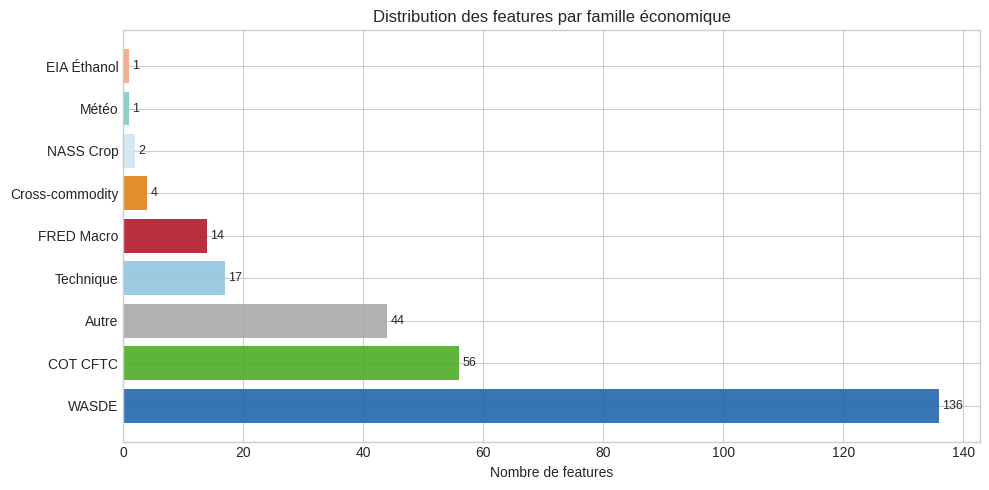

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {
    'WASDE': '#2166ac', 'COT CFTC': '#4dac26', 'Météo': '#80cdc1',
    'EIA Éthanol': '#f4a582', 'NASS Crop': '#d1e5f0', 'FRED Macro': '#b2182b',
    'Technique': '#92c5de', 'Cross-commodity': '#e08214', 'Autre': '#aaa'
}
cols = [colors_map.get(f, '#aaa') for f in fam_counts.index]
ax.barh(fam_counts.index, fam_counts.values, color=cols, alpha=0.9)
ax.set_xlabel('Nombre de features')
ax.set_title('Distribution des features par famille économique')
for i, v in enumerate(fam_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Couverture temporelle par famille

Certaines sources (WASDE, COT) ont des données historiques courtes ou des trous.
On mesure la couverture annuelle pour identifier les périodes utilisables.

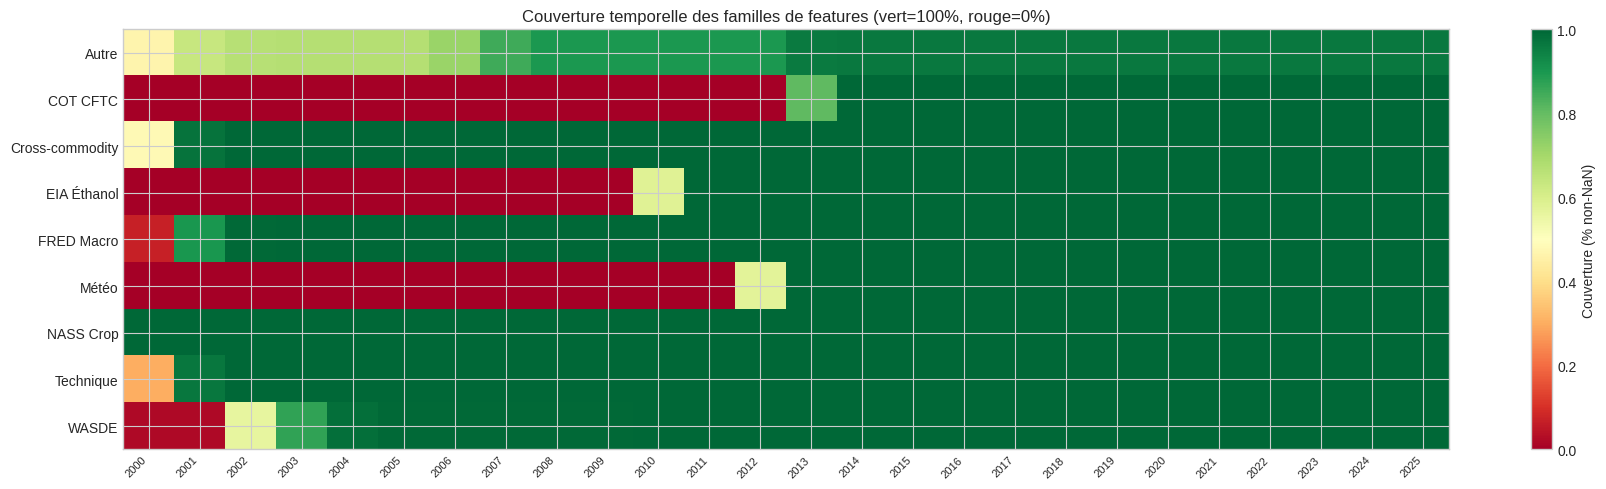

In [5]:
coverage_df = compute_coverage(feat, group_col='year')

# Couverture moyenne par famille × année
cov_pivot = coverage_df.groupby(['famille', 'année'])['couverture'].mean().reset_index()
cov_wide = cov_pivot.pivot(index='famille', columns='année', values='couverture')

fig, ax = plt.subplots(figsize=(18, max(5, len(cov_wide)*0.5)))
im = ax.imshow(cov_wide.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_yticks(range(len(cov_wide.index)))
ax.set_yticklabels(cov_wide.index, fontsize=10)
ax.set_xticks(range(len(cov_wide.columns)))
ax.set_xticklabels(cov_wide.columns, rotation=45, ha='right', fontsize=8)
plt.colorbar(im, ax=ax, label='Couverture (% non-NaN)')
ax.set_title('Couverture temporelle des familles de features (vert=100%, rouge=0%)')
plt.tight_layout()
plt.show()

## 3. Corrélations brutes avec la cible H=20j

On mesure |r| de Pearson et Spearman entre chaque feature et `y_logret_h20`.
C'est une mesure naïve (pas de walk-forward) — valeur diagnostique uniquement.

**Attention** : une corrélation élevée ici N'implique pas de causalité ni de signal OOS.

In [6]:
TARGET = 'y_logret_h20'

corr_df = compute_correlations(feat, tgt, target_col=TARGET, min_obs=100)

print(f"Features avec corrélation calculée : {len(corr_df)}")
print("\nTop 20 features (|r| Pearson) :")
print(corr_df.head(20)[['col', 'famille', 'pearson', 'spearman', 'n']].to_string(index=False))

Features avec corrélation calculée : 273

Top 20 features (|r| Pearson) :
                                    col         famille  pearson  spearman    n
                       corn_wheat_ratio Cross-commodity 0.216346  0.171162 6171
                                doy_cos           Autre 0.194669  0.190192 6172
                              month_cos           Autre 0.190972  0.186391 6172
                            cot_pm_long        COT CFTC 0.164622  0.141639 3132
                         wx_belt_tmax_c           Autre 0.163421  0.158395 6172
                         wx_belt_tavg_c           Autre 0.162505  0.157556 6172
               wasde_production_yoy_pct           WASDE 0.160514  0.169420 5617
                         wx_belt_tmin_c           Autre 0.159785  0.154334 6172
                      is_silking_season       NASS Crop 0.153689  0.124546 6172
                      corn_wheat_corr60 Cross-commodity 0.145471  0.135671 6131
                            corn_sma_50       

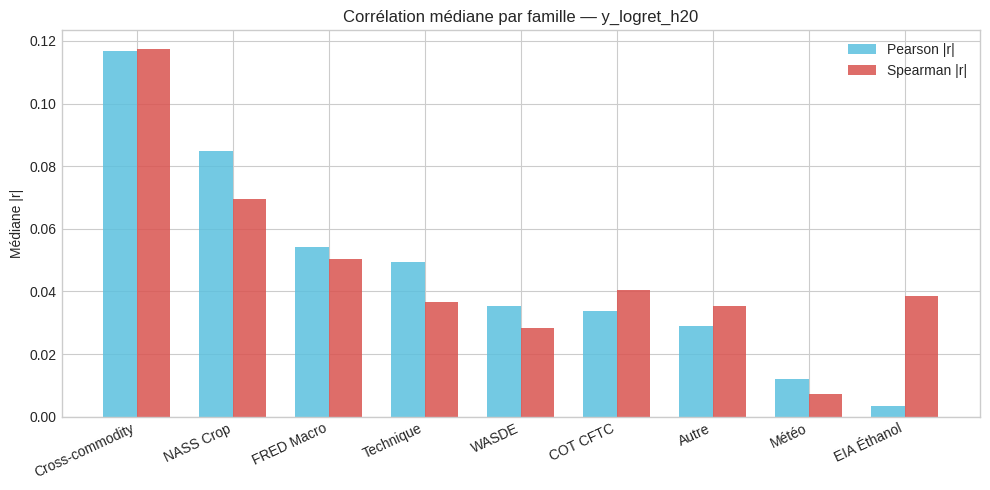


Corélation médiane par famille :
                  pearson  spearman
famille                            
Cross-commodity  0.116767  0.117501
NASS Crop        0.084691  0.069601
FRED Macro       0.054093  0.050198
Technique        0.049504  0.036701
WASDE            0.035465  0.028396
COT CFTC         0.033630  0.040527
Autre            0.029099  0.035185
Météo            0.011903  0.007129
EIA Éthanol      0.003500  0.038566


In [7]:
# Par famille — médiane de |r|
fam_corr = corr_df.groupby('famille')[['pearson', 'spearman']].median().sort_values('pearson', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(fam_corr))
w = 0.35
ax.bar([i - w/2 for i in x], fam_corr['pearson'], w, label='Pearson |r|', color='#5bc0de', alpha=0.85)
ax.bar([i + w/2 for i in x], fam_corr['spearman'], w, label='Spearman |r|', color='#d9534f', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(fam_corr.index, rotation=25, ha='right')
ax.set_ylabel('Médiane |r|')
ax.set_title(f'Corrélation médiane par famille — {TARGET}')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCorélation médiane par famille :")
print(fam_corr.to_string())

## 4. Signal par famille selon l'horizon

Le signal de chaque famille change-t-il avec l'horizon de prédiction ?
On s'attend à ce que les features techniques soient fortes à court terme (H=5j)
et les fondamentaux (WASDE, COT) plus utiles à long terme (H=20j, H=30j).

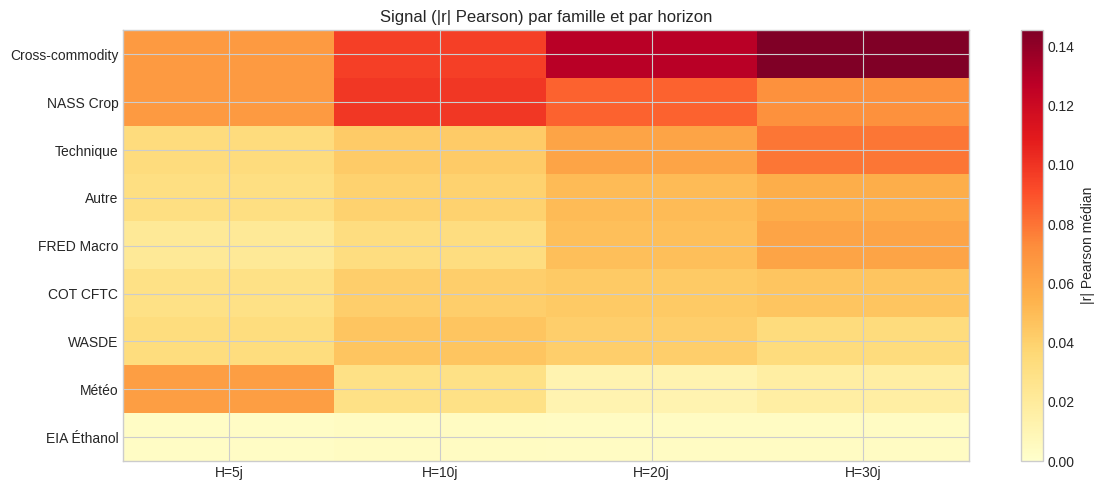

In [8]:
corr_by_h = compute_correlations_by_horizon(feat, tgt)

if not corr_by_h.empty:
    pivot_h = corr_by_h.pivot(index='famille', columns='horizon', values='pearson')
    pivot_h = pivot_h.loc[pivot_h.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, max(5, len(pivot_h)*0.45)))
    im = ax.imshow(pivot_h.values, cmap='YlOrRd', aspect='auto',
                   vmin=0, vmax=pivot_h.values.max())
    ax.set_yticks(range(len(pivot_h.index)))
    ax.set_yticklabels(pivot_h.index, fontsize=10)
    ax.set_xticks(range(len(pivot_h.columns)))
    ax.set_xticklabels([f'H={h}j' for h in pivot_h.columns], fontsize=10)
    plt.colorbar(im, ax=ax, label='|r| Pearson médian')
    ax.set_title('Signal (|r| Pearson) par famille et par horizon')
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez d'horizons disponibles pour la comparaison.")

## 5. Facteurs synthétiques (si disponibles)

Si `factors.parquet` existe, il contient les 48 facteurs déjà construits.
On vérifie leur répartition par famille et leur corrélation avec la cible.

Facteurs synthétiques : 16

Top 15 facteurs (|r| Pearson avec y_logret_h20) :
factor_market_momentum           NaN
factor_market_volatility         NaN
factor_wasde_supply_demand       NaN
factor_weather_belt_stress       NaN
factor_seasonality               NaN
factor_cross_commodity           NaN
factor_positioning               NaN
factor_raw_signal                NaN
factor_drought_severity          NaN
factor_export_demand_surprise    NaN
factor_crop_condition_pressure   NaN
factor_ethanol_demand            NaN
factor_curve_structure           NaN
factor_macro_em                  NaN
factor_world_supply              NaN


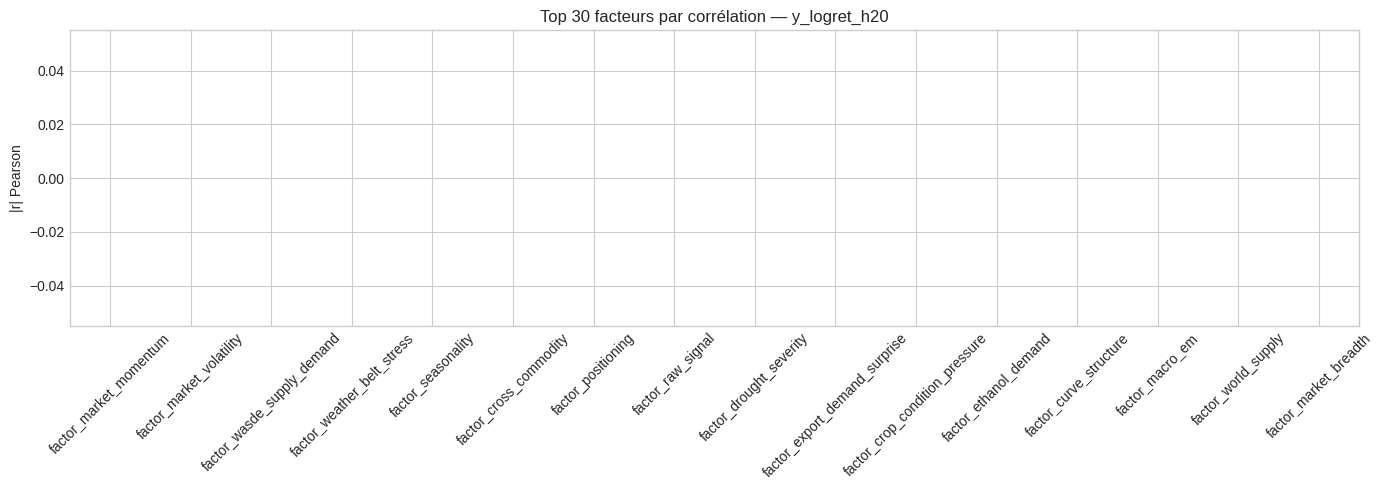

In [9]:
if fac is not None:
    factor_cols = [c for c in fac.columns if c.startswith('factor_')]
    print(f"Facteurs synthétiques : {len(factor_cols)}")

    fac_merged = fac.merge(tgt[['Date', TARGET]], on='Date', how='inner').dropna()
    X_fac = fac_merged[factor_cols].fillna(0)
    y_fac = fac_merged[TARGET]

    # Corrélation facteurs × cible
    fac_corr = pd.Series(
        {c: abs(float(X_fac[c].corr(y_fac))) for c in factor_cols}
    ).sort_values(ascending=False)

    print(f"\nTop 15 facteurs (|r| Pearson avec {TARGET}) :")
    print(fac_corr.head(15).to_string())

    fig, ax = plt.subplots(figsize=(14, 5))
    fac_corr.head(30).plot(kind='bar', ax=ax, color='#5bc0de', alpha=0.85)
    ax.set_title(f'Top 30 facteurs par corrélation — {TARGET}')
    ax.set_ylabel('|r| Pearson')
    ax.tick_params(axis='x', labelrotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("factors.parquet non disponible.")
    print("Les facteurs seront construits dans le cadre du benchmark modèles (notebook 06).")

## 6. Problème identifié : dominance de la famille 'Autre'

Si la famille 'Autre' représente >50% des features, c'est un signal que la classification
FAMILY_RULES est incomplète. Les features non classées ne seront pas interprétables
dans les analyses SHAP par famille.

**Action requise si 'Autre' > 30%** : enrichir `FAMILY_RULES` dans `mais.research.data_quality`.

In [10]:
pct_autre = fam_counts.get('Autre', 0) / fam_counts.sum() * 100
print(f"Famille 'Autre' : {fam_counts.get('Autre', 0)} features ({pct_autre:.1f}%)")

if pct_autre > 30:
    print("⚠️  Plus de 30% non classées — enrichir FAMILY_RULES dans mais.research.data_quality")
    unclassified = [c for c, f in families.items() if f == 'Autre']
    print(f"\nExemples de features non classées :")
    for c in unclassified[:15]:
        print(f"  {c}")
else:
    print("Classification satisfaisante (< 30% non classées)")

Famille 'Autre' : 44 features (16.0%)
Classification satisfaisante (< 30% non classées)


## 7. Conclusions

### Ce qu'on retient

1. **Familles identifiées** : 8 familles économiques couvrent la grande majorité des features
2. **Hiérarchie du signal** (à vérifier empiriquement) :
   - Technique → signal fort à court terme (H=5j), s'affaiblit à H=20j
   - COT CFTC → positionnement des traders, signal moyen terme
   - WASDE → fondamentaux mensuels, signal long terme (H=20–30j)
   - Météo → signal concentré sur mai–août (période végétation)
3. **Coverage** : certaines sources (NASS Crop Progress, EIA Éthanol) ont une couverture limitée
   avant 2010 — les modèles doivent être entraînés sur la période de couverture complète

### Ce qu'on NE fait PAS
- Utiliser la corrélation brute comme signal de trading (pas de walk-forward ici)
- Ignorer les features 'Autre' — les inspecter et recalssifier si possible

### Suite
- **Notebook 04** : reformuler les targets (`y_store`, `y_up`, `y_regret`) pour aligner sur la
  vraie décision agriculteur
- **Notebook 06** : benchmark walk-forward sur les facteurs vs features brutes

In [11]:
elog = ExperimentLogger()
eid = elog.new(
    title="Framework facteurs — classification 249 features en 8 familles",
    hypothesis="Les familles COT et WASDE ont le signal prédictif le plus élevé à H=20j",
    method="classify_column + compute_coverage + compute_correlations_by_horizon",
    result="A compléter après exécution — noter les familles top-3 par |r| médian",
    decision="neutral",
    notes="Vérifier % famille Autre — si > 30% enrichir FAMILY_RULES. Comparer résultats avec SHAP notebook 06.",
)
print(f"Expérience enregistrée : {eid}")

Expérience enregistrée : EXP-007
